In [1]:
import pandas as pd
import numpy as np

In [23]:
questions_df= pd.read_csv('my_data_q.csv')
questions_df.head()

,quesNo,subjects,lokNo,member,ministry,type,date,questionText,answerText,questionsFilePath,questionsFilePathHindi,sessionNo,supplementaryQuestionResDtoList,supplementaryType,year
0,3008,"Toll Plazas in Dharmapuri, Tamil Nadu ...",18,Shri Mani A,ROAD TRANSPORT AND HIGHWAYS,UNSTARRED,2025-12-18,NaN,NaN,https://sansad.in/getFile/loksabhaquestions/an...,https://sansad.in/getFile/loksabhaquestions/qh...,6,NaN,False,2025
1,2960,Programmes to improve Connectivity/Lo...,18,Shri Mani A,RAILWAYS,UNSTARRED,2025-12-17,NaN,NaN,https://sansad.in/getFile/loksabhaquestions/an...,https://sansad.in/getFile/loksabhaquestions/qh...,6,NaN,False,2025
2,2570,Schemes to promote Skill Development among Far...,18,Shri Mani A,AGRICULTURE AND FARMERS WELFARE,UNSTARRED,2025-12-16,NaN,NaN,https://sansad.in/getFile/loksabhaquestions/an...,https://sansad.in/getFile/loksabhaquestions/qh...,6,NaN,False,2025
3,2401,Contribution of States in Tourism Industry ...,18,Shri Mani A,TOURISM,UNSTARRED,2025-12-15,NaN,NaN,https://sansad.in/getFile/loksabhaquestions/an...,https://sansad.in/getFile/loksabhaquestions/qh...,6,NaN,False,2025
4,2226,Pharmacovigilance System for AYUSH Drugs,18,"Shri E T Mohammed Basheer, Shri Mani A",AYUSH,UNSTARRED,2025-12-12,NaN,NaN,https://sansad.in/getFile/loksabhaquestions/an...,https://sansad.in/getFile/loksabhaquestions/qh...,6,NaN,False,2025


In [24]:
questions_df = questions_df.drop(columns=['questionText', 'answerText', 'questionsFilePath','questionsFilePathHindi','supplementaryQuestionResDtoList'])
questions_df.tail(16)

,quesNo,subjects,lokNo,member,ministry,type,date,sessionNo,supplementaryType,year
37255,2846,Initiatives undertaken to promote Organic Farm...,18,Mr Pathan Yusuf,AGRICULTURE AND FARMERS WELFARE,UNSTARRED,2025-03-18,4,False,2025
37256,2602,Reduction in Subsidies for Essential Commodities,18,Mr Pathan Yusuf,FINANCE,UNSTARRED,2025-03-17,4,False,2025
37257,2418,Revenue Collected through Central Excise Duty ...,18,Mr Pathan Yusuf,PETROLEUM AND NATURAL GAS,UNSTARRED,2025-03-13,4,False,2025
37258,1413,Hike in Airfare,18,"Mr Pathan Yusuf, Ms Sayani Ghosh, Shri Y S Avi...",CIVIL AVIATION,UNSTARRED,2025-02-13,4,False,2025
37259,1189,Skill Development Programmes ...,18,Mr Pathan Yusuf,"FISHERIES, ANIMAL HUSBANDRY AND DAIRYING",UNSTARRED,2025-02-11,4,False,2025
37260,942,Utilisation of Funds Allocated to Central Uni...,18,Mr Pathan Yusuf,EDUCATION,UNSTARRED,2025-02-10,4,False,2025
37261,789,Muslim Expatriates Working in Gulf Countries,18,Mr Pathan Yusuf,EXTERNAL AFFAIRS,UNSTARRED,2025-02-07,4,False,2025
37262,566,Flights from Kolkata Airport to Middle East Co...,18,Mr Pathan Yusuf,CIVIL AVIATION,UNSTARRED,2025-02-06,4,False,2025
37263,20,Financial Crisis in Central Universities ...,18,Mr Pathan Yusuf,EDUCATION,UNSTARRED,2025-02-03,4,False,2025
37264,4208,Expenditure on CGHS ...,18,Mr Pathan Yusuf,HEALTH AND FAMILY WELFARE,UNSTARRED,2024-12-20,3,False,2024


In [27]:
questions_df['member'].unique()

array(['Shri Mani A', 'Shri E T Mohammed Basheer, Shri Mani A',
       'Shri Navaskani K, Shri Selvam G, Shri Mani A, Shri C N Annadurai',
       ..., 'Shri Giridhari Yadav', 'Smt. Dimple Yadav',
       'Mr Pathan Yusuf'], shape=(3938,), dtype=object)

In [9]:
questions_df['supplementaryType'].dtype

dtype('bool')

C:\Users\haank\AppData\Local\Temp\ipykernel_16632\1981708942.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_ministries.values, y=top_ministries.index, palette="viridis")


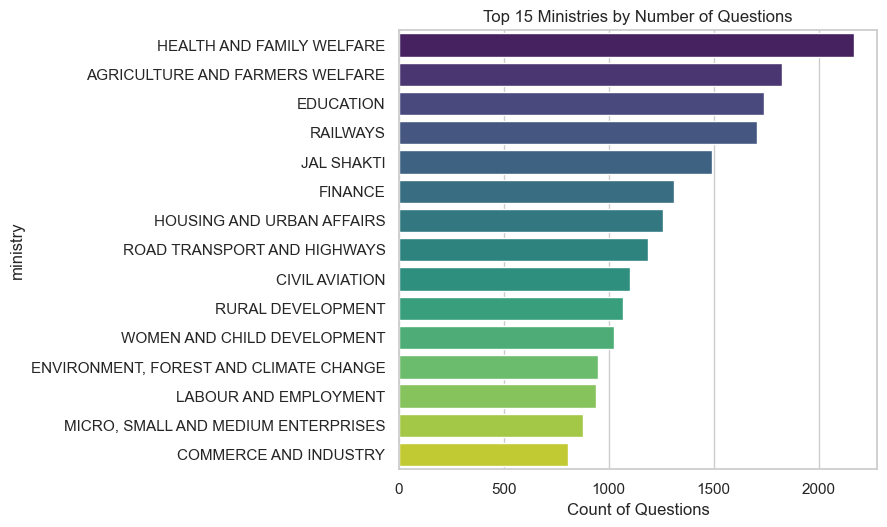

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your dataframe is named 'df'
# Preprocessing: Ensure date column is datetime format
questions_df['date'] = pd.to_datetime(questions_df['date'])

# Set standard plotting style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 10))

# -----------------------------------------------------------------
# PLOT 1: Top 15 Ministries
# -----------------------------------------------------------------
plt.subplot(2, 2, 1)
top_ministries = questions_df['ministry'].value_counts().head(15)
sns.barplot(x=top_ministries.values, y=top_ministries.index, palette="viridis")
plt.title('Top 15 Ministries by Number of Questions')
plt.xlabel('Count of Questions')

# -----------------------------------------------------------------
# PLOT 2: Question Type Distribution
# -----------------------------------------------------------------
''''plt.subplot(2, 2, 2)
questions_df['type'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette("pastel"), startangle=90)
plt.title('Distribution of Question Types')
plt.ylabel('') # Hides the default column label

# -----------------------------------------------------------------
# PLOT 3: Questions Over Time (Grouped Monthly)
# -----------------------------------------------------------------
plt.subplot(2, 2, 3)
questions_over_time = questions_df.groupby(df['date'].dt.to_period('M')).size()
questions_over_time.plot(kind='line', marker='o', color='b', linewidth=2)
plt.title('Trend of Questions Filed Over Time')
plt.xlabel('Month-Year')
plt.ylabel('Number of Questions')

# -----------------------------------------------------------------
# PLOT 4: Top 10 Most Active Members
# -----------------------------------------------------------------
plt.subplot(2, 2, 4)
# Splitting string if multiple members are listed in a single row
split_members = questions_df['member'].str.split(', ').explode()
top_members = split_members.value_counts().head(10)
sns.barplot(x=top_members.values, y=top_members.index, palette="magma")
plt.title('Top 10 Most Active Members')
plt.xlabel('Count of Questions Asked')'''

# Adjust layout spacing and show/save plots
plt.tight_layout()

plt.show()

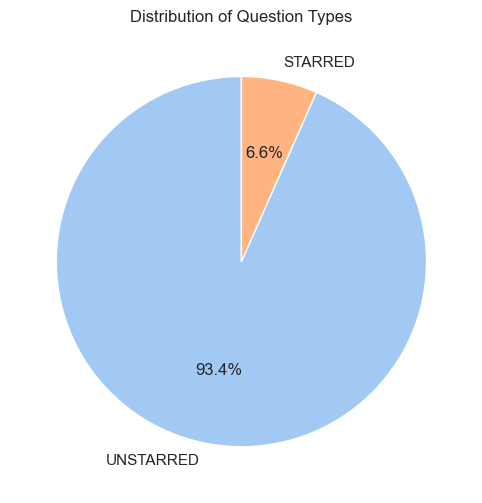

In [17]:
# -----------------------------------------------------------------
# PLOT 2: Question Type Distribution
# -----------------------------------------------------------------
plt.figure(figsize=(14, 10))
plt.subplot(2, 2, 2)
questions_df['type'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette("pastel"), startangle=90)
plt.title('Distribution of Question Types')
plt.ylabel('') # Hides the default column label

plt.tight_layout()

plt.show()

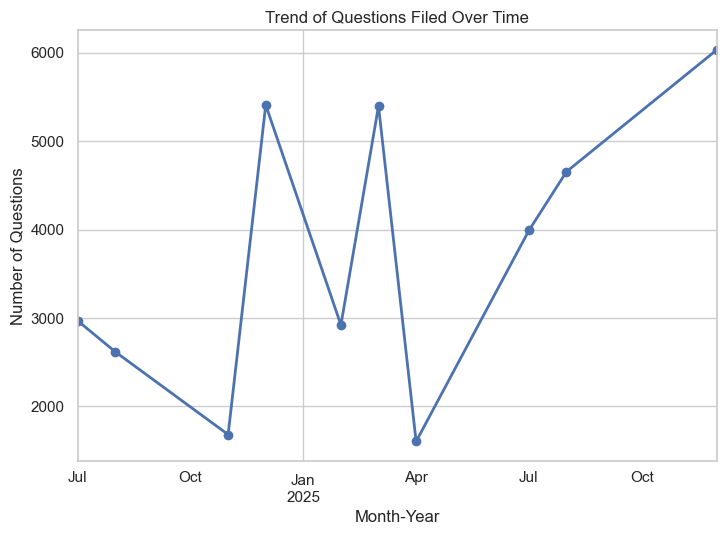

In [18]:
# -----------------------------------------------------------------
# PLOT 3: Questions Over Time (Grouped Monthly)
# -----------------------------------------------------------------
plt.figure(figsize=(14, 10))
plt.subplot(2, 2, 3)
questions_over_time = questions_df.groupby(questions_df['date'].dt.to_period('M')).size()
questions_over_time.plot(kind='line', marker='o', color='b', linewidth=2)
plt.title('Trend of Questions Filed Over Time')
plt.xlabel('Month-Year')
plt.ylabel('Number of Questions')

plt.tight_layout()

plt.show()

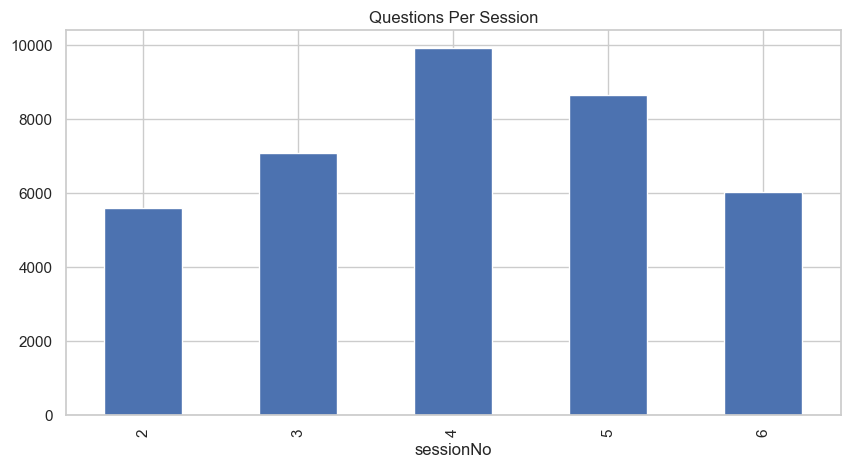

In [32]:
questions_df["sessionNo"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Questions Per Session")
plt.show()

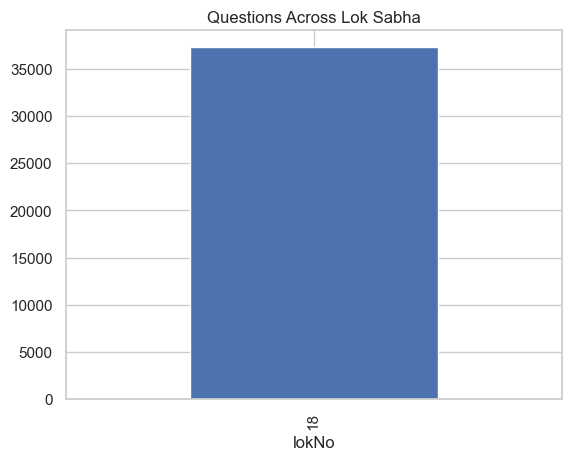

In [33]:
questions_df["lokNo"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Questions Across Lok Sabha")
plt.show()

<Axes: xlabel='supplementaryType'>

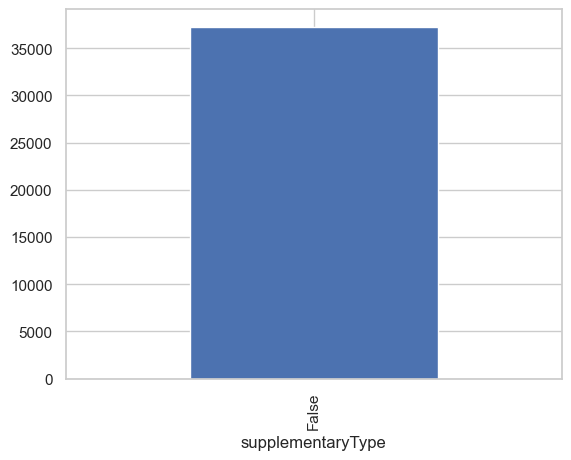

In [34]:
questions_df["supplementaryType"].value_counts().plot(
    kind="bar"
)

Text(0.5, 1.0, 'Ministry vs Question Type')

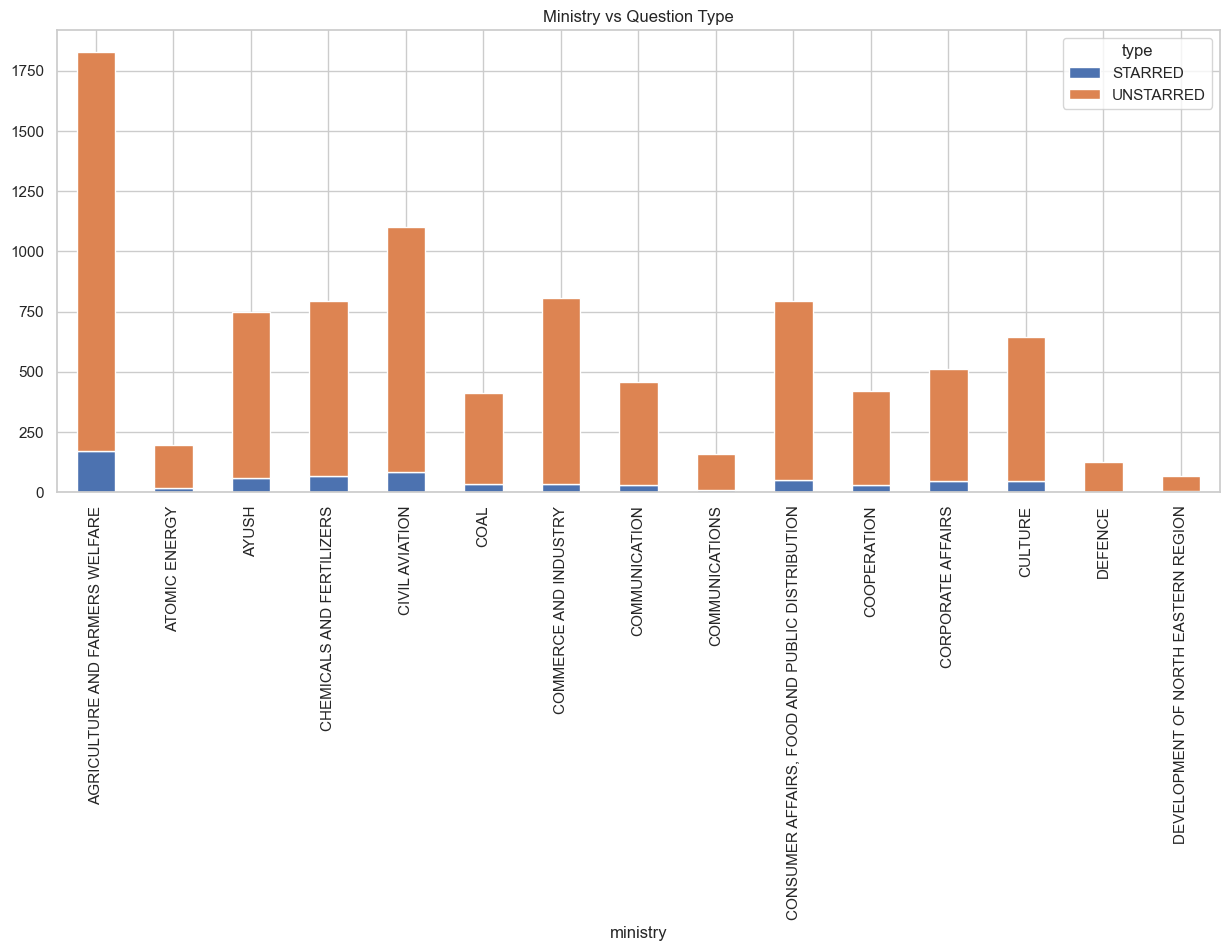

In [36]:

cross = pd.crosstab(
    questions_df["ministry"],
    questions_df["type"]
)

cross.head(15).plot(
    kind="bar",
    stacked=True,
    figsize=(15,6)
)
plt.title('Ministry vs Question Type')


<Axes: xlabel='ministry', ylabel='year'>

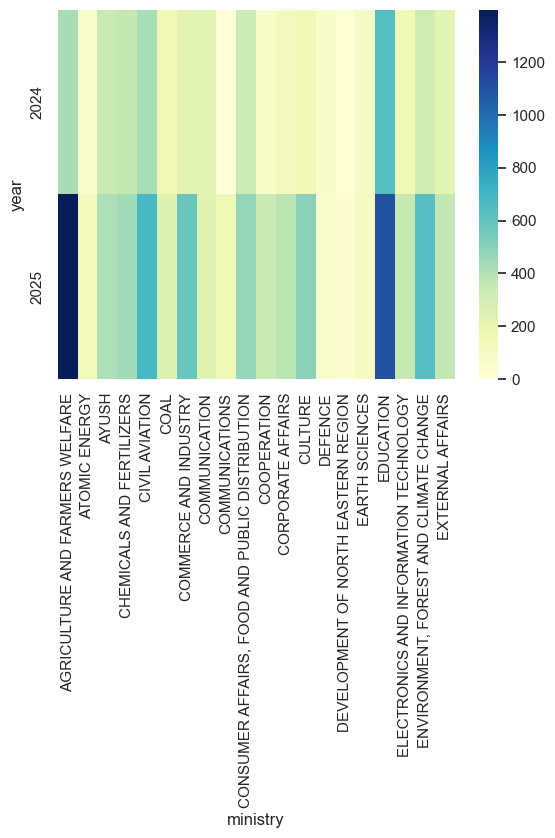

In [37]:
pivot = pd.crosstab(
    questions_df["year"],
    questions_df["ministry"]
)
sns.heatmap(
    pivot.iloc[:, :20],
    cmap="YlGnBu"
)

C:\Users\haank\AppData\Local\Temp\ipykernel_16632\4064879851.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_members.values, y=top_members.index, palette="magma")


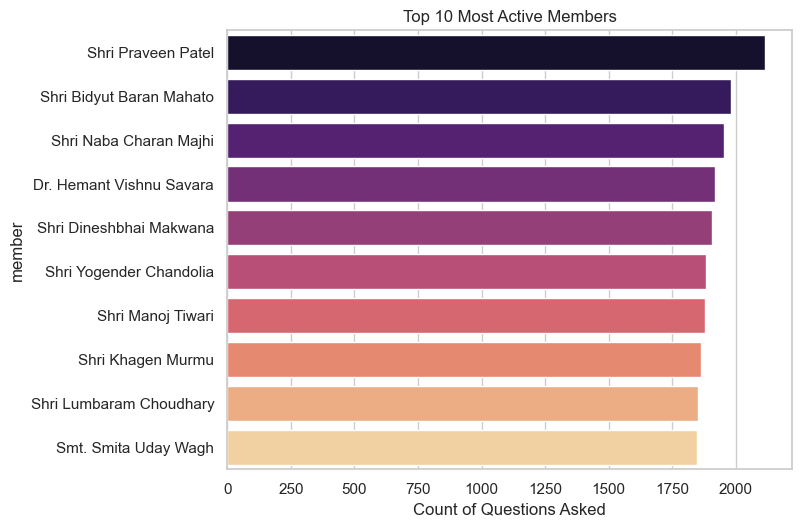

In [19]:
# -----------------------------------------------------------------
# PLOT 4: Top 10 Most Active Members
# -----------------------------------------------------------------
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 4)
# Splitting string if multiple members are listed in a single row
split_members = questions_df['member'].str.split(', ').explode()
top_members = split_members.value_counts().head(10)
sns.barplot(x=top_members.values, y=top_members.index, palette="magma")
plt.title('Top 10 Most Active Members')
plt.xlabel('Count of Questions Asked')

plt.tight_layout()

plt.show()

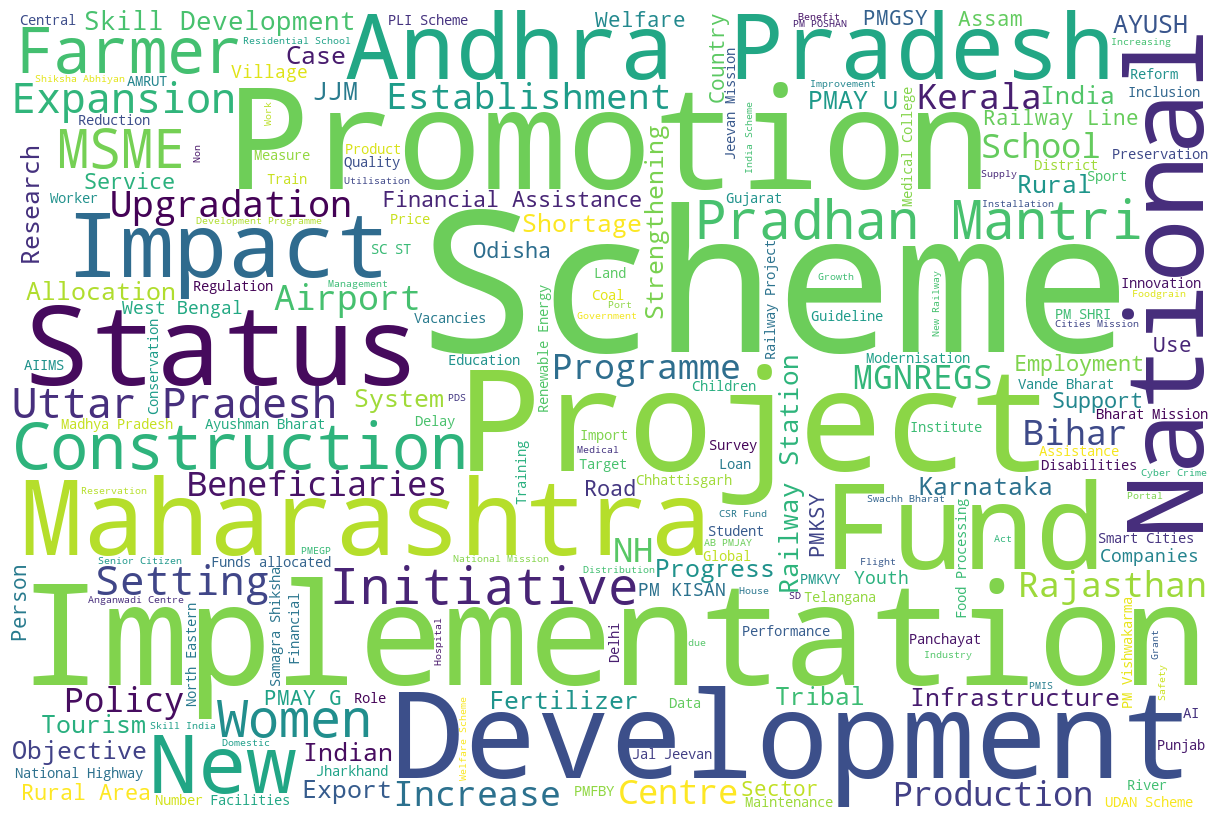

In [20]:

from wordcloud import WordCloud, STOPWORDS

# Assuming your dataframe is named 'df'
# 1. Clean the text data by removing missing values and converting to strings
text_data = questions_df['subjects'].dropna().astype(str)

# 2. Combine all rows into a single long string
combined_text = " ".join(text_data)

# 3. Add custom stop words specific to your dataset if needed
custom_stopwords = set(STOPWORDS)
custom_stopwords.update(["Tamil", "Nadu", "Dharmapuri", "State", "States"]) 
# Note: Add any specific state names or words like "Scheme" if they dominate too much

# 4. Generate the word cloud
wordcloud = WordCloud(
    width=1200, 
    height=800, 
    background_color='white',
    stopwords=custom_stopwords,
    colormap='viridis',      # Change to 'plasma', 'inferno', or 'magma' for different colors
    min_font_size=10
).generate(combined_text)

# 5. Display the generated image
plt.figure(figsize=(12, 8), facecolor=None)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.tight_layout(pad=0)

plt.show()


In [21]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


C:\Users\haank\AppData\Local\Temp\ipykernel_16632\1593683802.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bigram_counts['count'], y=bigram_counts.index, palette="Blues_r")


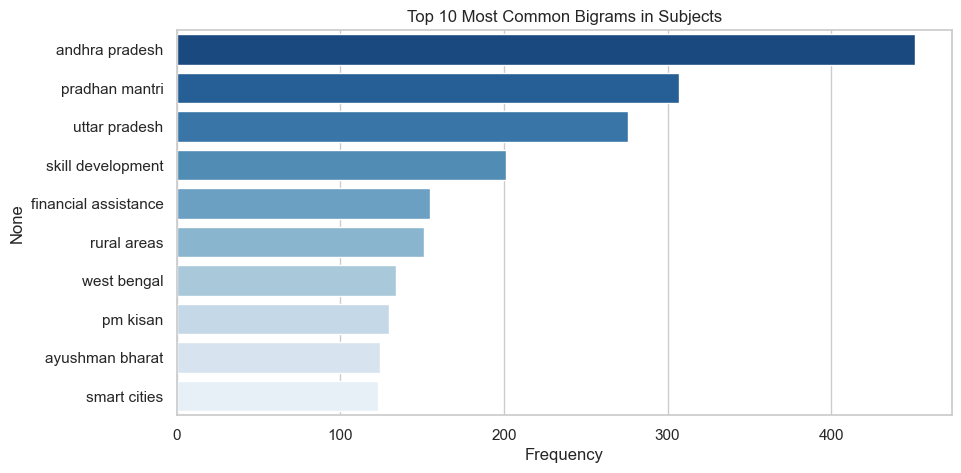

In [29]:

from sklearn.feature_extraction.text import CountVectorizer

# Combine custom stop words with English defaults
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
custom_stops = list(ENGLISH_STOP_WORDS) + ['tamil', 'nadu', 'dharmapuri', 'shri', 'mani']

# Initialize vectorizer for 2-word phrases (ngram_range=(2,2))
vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words=custom_stops)

# Fit and transform the clean text data
text_data = questions_df['subjects'].dropna().astype(str)
bigram_matrix = vectorizer.fit_transform(text_data)

# Sum up occurrences and create a DataFrame
bigram_counts = pd.DataFrame(
    bigram_matrix.sum(axis=0).T, 
    index=vectorizer.get_feature_names_out(), 
    columns=['count']
).sort_values(by='count', ascending=False).head(10)

# Plot the top bigrams
plt.figure(figsize=(10, 5))
sns.barplot(x=bigram_counts['count'], y=bigram_counts.index, palette="Blues_r")
plt.title('Top 10 Most Common Bigrams in Subjects')
plt.xlabel('Frequency')
plt.show()


In [30]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer

# Vectorize words using TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, stop_words=custom_stops)
tfidf_matrix = tfidf_vectorizer.fit_transform(text_data)

# Train the Latent Dirichlet Allocation model for 5 topics
lda_model = LatentDirichletAllocation(n_components=5, random_state=42)
lda_model.fit(tfidf_matrix)

# Print the top 8 words describing each topic
words = tfidf_vectorizer.get_feature_names_out()
for idx, topic in enumerate(lda_model.components_):
    top_words_idx = topic.argsort()[:-9:-1]
    top_words = [words[i] for i in top_words_idx]
    print(f"**Topic #{idx+1} Key Terms:** {', '.join(top_words)}")


**Topic #1 Key Terms:** pm, mission, scheme, national, ayush, centres, areas, rural
**Topic #2 Key Terms:** tourism, promotion, india, scheme, cases, national, csr, programme
**Topic #3 Key Terms:** scheme, production, financial, coal, mission, implementation, agricultural, projects
**Topic #4 Key Terms:** pradesh, bharat, schemes, funds, projects, water, railway, portal
**Topic #5 Key Terms:** scheme, development, msmes, food, support, sector, energy, skill


In [31]:
questions_df.to_csv("my_data_q.csv", index=False)